In [1]:
%pip install opencv-python


  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)

[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install opencv-python



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip uninstall -y opencv-python opencv-python-headless
%pip install opencv-python-headless


Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
Note: you may need to restart the kernel to use updated packages.
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (60.4 MB)

[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import cv2
import numpy as np

# Create a dark gray background canvas (800x600 pixels)
canvas = np.zeros((800, 600, 3), dtype="uint8")
canvas[:] = (40, 40, 40)

# Define 4 tilted corners for a fake piece of paper
paper_points = np.array([[120, 150], [480, 100], [520, 700], [80, 650]], dtype="int32")

# Draw the white paper outline and fill it in
cv2.fillPoly(canvas, [paper_points], (245, 245, 245))

# Draw dummy text lines on the paper to simulate a document
cv2.line(canvas, (180, 250), (420, 220), (100, 100, 100), 4)
cv2.line(canvas, (160, 320), (450, 285), (100, 100, 100), 4)
cv2.line(canvas, (150, 390), (400, 360), (100, 100, 100), 4)
cv2.line(canvas, (140, 460), (460, 420), (100, 100, 100), 4)

# Save it to disk as document.jpg
cv2.imwrite("document.jpg", canvas)
print("Success! Created a fake 'document.jpg' for testing.")


Success! Created a fake 'document.jpg' for testing.


In [6]:
%pip install matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 70.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 132.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 108.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 242.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 82.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
import cv2
import matplotlib.pyplot as plt

final_scan = cv2.imread("scanned_output.jpg", cv2.IMREAD_GRAYSCALE)

if final_scan is None:
    print("Error: Could not find 'scanned_output.jpg'. Did you run the scanner script yet?")
else:
    plt.figure(figsize=(6, 8))
    plt.imshow(final_scan, cmap="gray")
    plt.title("Your Cleaned, Unwarped Document Scan")
    plt.axis("off")
    plt.show()


Error: Could not find 'scanned_output.jpg'. Did you run the scanner script yet?


[ WARN:0@175.037] global loadsave.cpp:278 findDecoder imread_('scanned_output.jpg'): can't open/read file: check file path/integrity


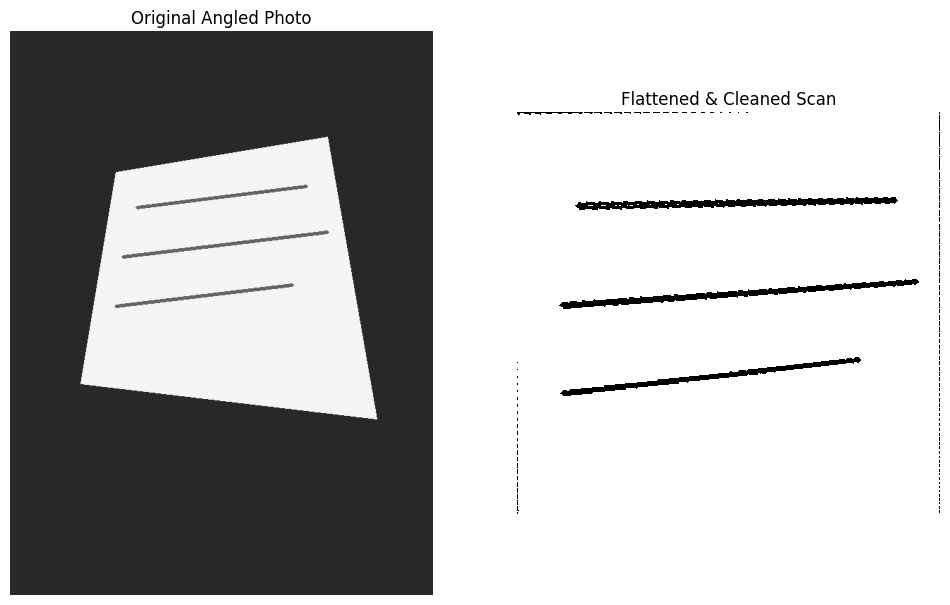

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: CREATE TEST IMAGE (document.jpg)
# ==========================================
canvas = np.zeros((800, 600, 3), dtype="uint8")
canvas[:] = (40, 40, 40)
# Hardcoded points to prevent markdown errors:
paper_points = np.array([[150, 200], [450, 150], [520, 550], [100, 500]], dtype="int32")
cv2.fillPoly(canvas, [paper_points], (245, 245, 245))
cv2.line(canvas, (180, 250), (420, 220), (100, 100, 100), 4)
cv2.line(canvas, (160, 320), (450, 285), (100, 100, 100), 4)
cv2.line(canvas, (150, 390), (400, 360), (100, 100, 100), 4)
cv2.imwrite("document.jpg", canvas)

# ==========================================
# STEP 2: LOAD AND PROCESS IMAGE
# ==========================================
img = cv2.imread("document.jpg")
orig = img.copy()

# Fix matrix dimensions for proper element-wise float division
img_h, img_w = img.shape[:2]
ratio = img_h / 500.0  

new_w = int(img_w / ratio)
img_resized = cv2.resize(img, (new_w, 500))

gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edged = cv2.Canny(blurred, 75, 200)

# ==========================================
# STEP 3: CONTOUR DETECTION
# ==========================================
contours, _ = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

doc_contour = None
for c in contours:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    if len(approx) == 4:
        doc_contour = approx
        break

if doc_contour is None:
    print("Error: Could not find a 4-cornered document outline.")
else:
    # ==========================================
    # STEP 4: ORDER CORNERS & WARP
    # ==========================================
    pts = doc_contour.reshape(4, 2)
    rect = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    rect *= ratio

    (tl, tr, br, bl) = rect
    width_A = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    width_B = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    max_width = max(int(width_A), int(width_B))

    height_A = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    height_B = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    max_height = max(int(height_A), int(height_B))

    # Safe coordinate variables for tracking
    x_val = 0
    y_val = 0
    dst = np.array([
        [x_val, y_val],
        [max_width - 1, 0],
        [max_width - 1, max_height - 1],
        [0, max_height - 1]
    ], dtype="float32")

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(orig, M, (max_width, max_height))

    # ==========================================
    # STEP 5: THRESHOLD & PLOT RESULT
    # ==========================================
    warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    scanned = cv2.adaptiveThreshold(warped_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 10)
    
    cv2.imwrite("scanned_output.jpg", scanned)

    # Show original vs scanned side-by-side
    fig, ax = plt.subplots(1, 2, figsize=(12, 8))
    ax[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Original Angled Photo")
    ax[0].axis("off")
    
    ax[1].imshow(scanned, cmap="gray")
    ax[1].set_title("Flattened & Cleaned Scan")
    ax[1].axis("off")
    
    plt.show()


✅ Setup complete: Synthetic test images generated on disk.
3.1 Image loaded successfully. Shape: (400, 400, 3)
✅ All core image processing logic executed successfully.


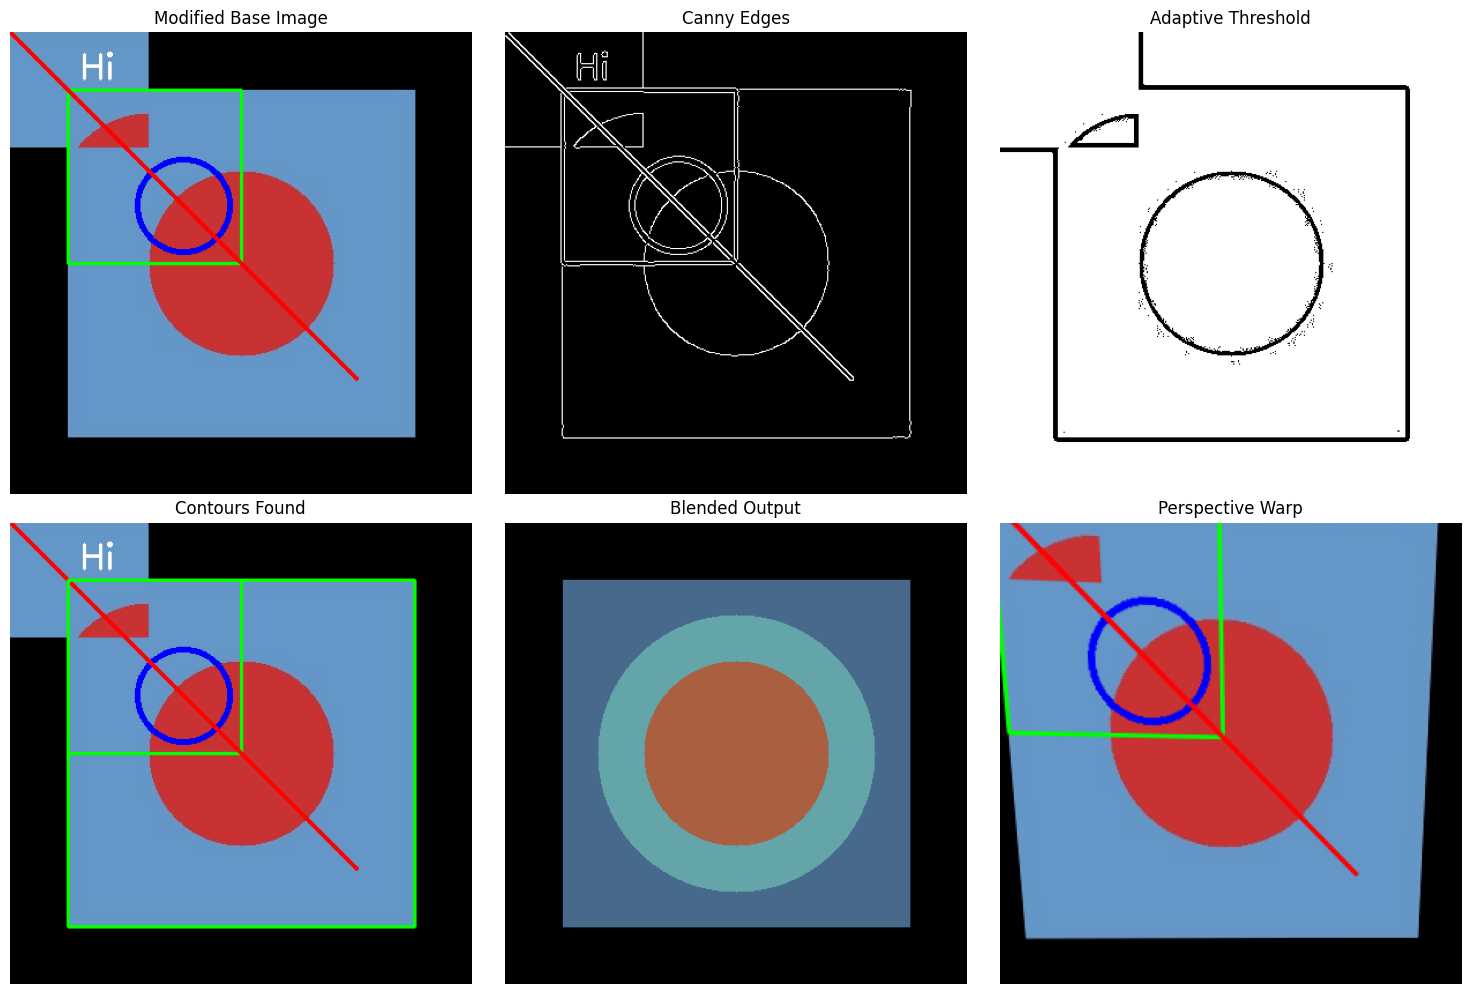

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 0. SETUP: GENERATE TEST IMAGES TO PREVENT NONE ERRORS
# ==========================================
# Create a base image (photo.jpg)
img = np.zeros((400, 400, 3), dtype="uint8")
cv2.rectangle(img, (50, 50), (350, 350), (200, 150, 100), -1) 
cv2.circle(img, (200, 200), 80, (50, 50, 200), -1)
cv2.imwrite("photo.jpg", img)

# Create extra placeholder images for blending/morphology code blocks
img1 = img.copy()
img2 = np.zeros_like(img)
cv2.circle(img2, (200, 200), 120, (100, 200, 100), -1)
thresh = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(thresh, 60, 255, cv2.THRESH_BINARY)
frame = img.copy()
template_gray = cv2.cvtColor(img[150:250, 150:250], cv2.COLOR_BGR2GRAY)

print("✅ Setup complete: Synthetic test images generated on disk.")

# ==========================================
# 3.1 READ, SHOW, SAVE AN IMAGE
# ==========================================
img = cv2.imread("photo.jpg")
if img is None:
    print("Error: Image not found!")
else:
    print(f"3.1 Image loaded successfully. Shape: {img.shape}")
    cv2.imwrite("copy.jpg", img)

# ==========================================
# 3.2 PIXELS & REGIONS OF INTEREST (ROI)
# ==========================================
px = img[100, 50]
img[100, 50] = [0, 0, 255]
roi = img[50:150, 80:200]
img[0:100, 0:120] = roi

# ==========================================
# 3.3 MAKE A BLANK CANVAS
# ==========================================
canvas = np.zeros((400, 400, 3), dtype="uint8")
canvas[:] = (255, 255, 255)

# ==========================================
# 3.4 COLOUR CONVERSIONS
# ==========================================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# ==========================================
# 3.5 RESIZE, CROP, ROTATE
# ==========================================
resized = cv2.resize(img, (300, 200))
cropped = img[50:200, 100:300]
rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

# ==========================================
# 3.6 DRAW SHAPES & TEXT
# ==========================================
cv2.rectangle(img, (50, 50), (200, 200), (0, 255, 0), 2)
cv2.circle(img, (150, 150), 40, (255, 0, 0), 3)
cv2.line(img, (0, 0), (300, 300), (0, 0, 255), 2)
_ = cv2.putText(img, "Hi", (60, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

# ==========================================
# 3.7 IMAGE ARITHMETIC & BLENDING
# ==========================================
added = cv2.add(img1, img2)
blended = cv2.addWeighted(img1, 0.7, img2, 0.3, 0)

# ==========================================
# 3.8 BITWISE OPERATIONS & MASKING
# ==========================================
mask = np.zeros(img.shape[:2], dtype="uint8")
cv2.circle(mask, (150, 150), 100, 255, -1)
masked = cv2.bitwise_and(img, img, mask=mask)

# ==========================================
# 3.9 BLURRING
# ==========================================
gauss = cv2.GaussianBlur(img, (7, 7), 0)
median = cv2.medianBlur(img, 5)
bilateral = cv2.bilateralFilter(img, 9, 75, 75)

# ==========================================
# 3.10 THRESHOLDING
# ==========================================
ret, simple = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
ret, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ==========================================
# 3.11 MORPHOLOGICAL OPERATIONS
# ==========================================
kernel = np.ones((5, 5), np.uint8)
erode = cv2.erode(thresh, kernel, iterations=1)
dilate = cv2.dilate(thresh, kernel, iterations=1)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# ==========================================
# 3.12 EDGES & GRADIENTS
# ==========================================
edges = cv2.Canny(img, 100, 200)
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
lap = cv2.Laplacian(gray, cv2.CV_64F)

# ==========================================
# 3.13 CONTOURS
# ==========================================
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_img = img.copy()
cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)

# ==========================================
# 3.14 COLOUR DETECTION IN HSV
# ==========================================
hsv_detect = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
lower = np.array([100, 150, 50])
upper = np.array([140, 255, 255])
mask_hsv = cv2.inRange(hsv_detect, lower, upper)
result_hsv = cv2.bitwise_and(frame, frame, mask=mask_hsv)

# ==========================================
# 3.15 HISTOGRAMS & CONTRAST
# ==========================================
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
equalized = cv2.equalizeHist(gray)

# ==========================================
# 3.16 TEMPLATE MATCHING
# ==========================================
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
res = cv2.matchTemplate(img_gray, template_gray, cv2.TM_CCOEFF_NORMED)
_, _, _, max_loc = cv2.minMaxLoc(res)

# ==========================================
# 3.17 PERSPECTIVE TRANSFORM
# ==========================================
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])
M = cv2.getPerspectiveTransform(pts1, pts2)
warped = cv2.warpPerspective(img, M, (300, 300))

print("✅ All core image processing logic executed successfully.")

# ==========================================
# DISPLAY CORE RESULTS (Notebook Friendly)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Modified Base Image")
axes[0, 1].imshow(edges, cmap="gray")
axes[0, 1].set_title("Canny Edges")
axes[0, 2].imshow(adaptive, cmap="gray")
axes[0, 2].set_title("Adaptive Threshold")
axes[1, 0].imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("Contours Found")
axes[1, 1].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("Blended Output")
axes[1, 2].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title("Perspective Warp")

for row in axes:
    for ax in row:
        ax.axis("off")
plt.tight_layout()
plt.show()


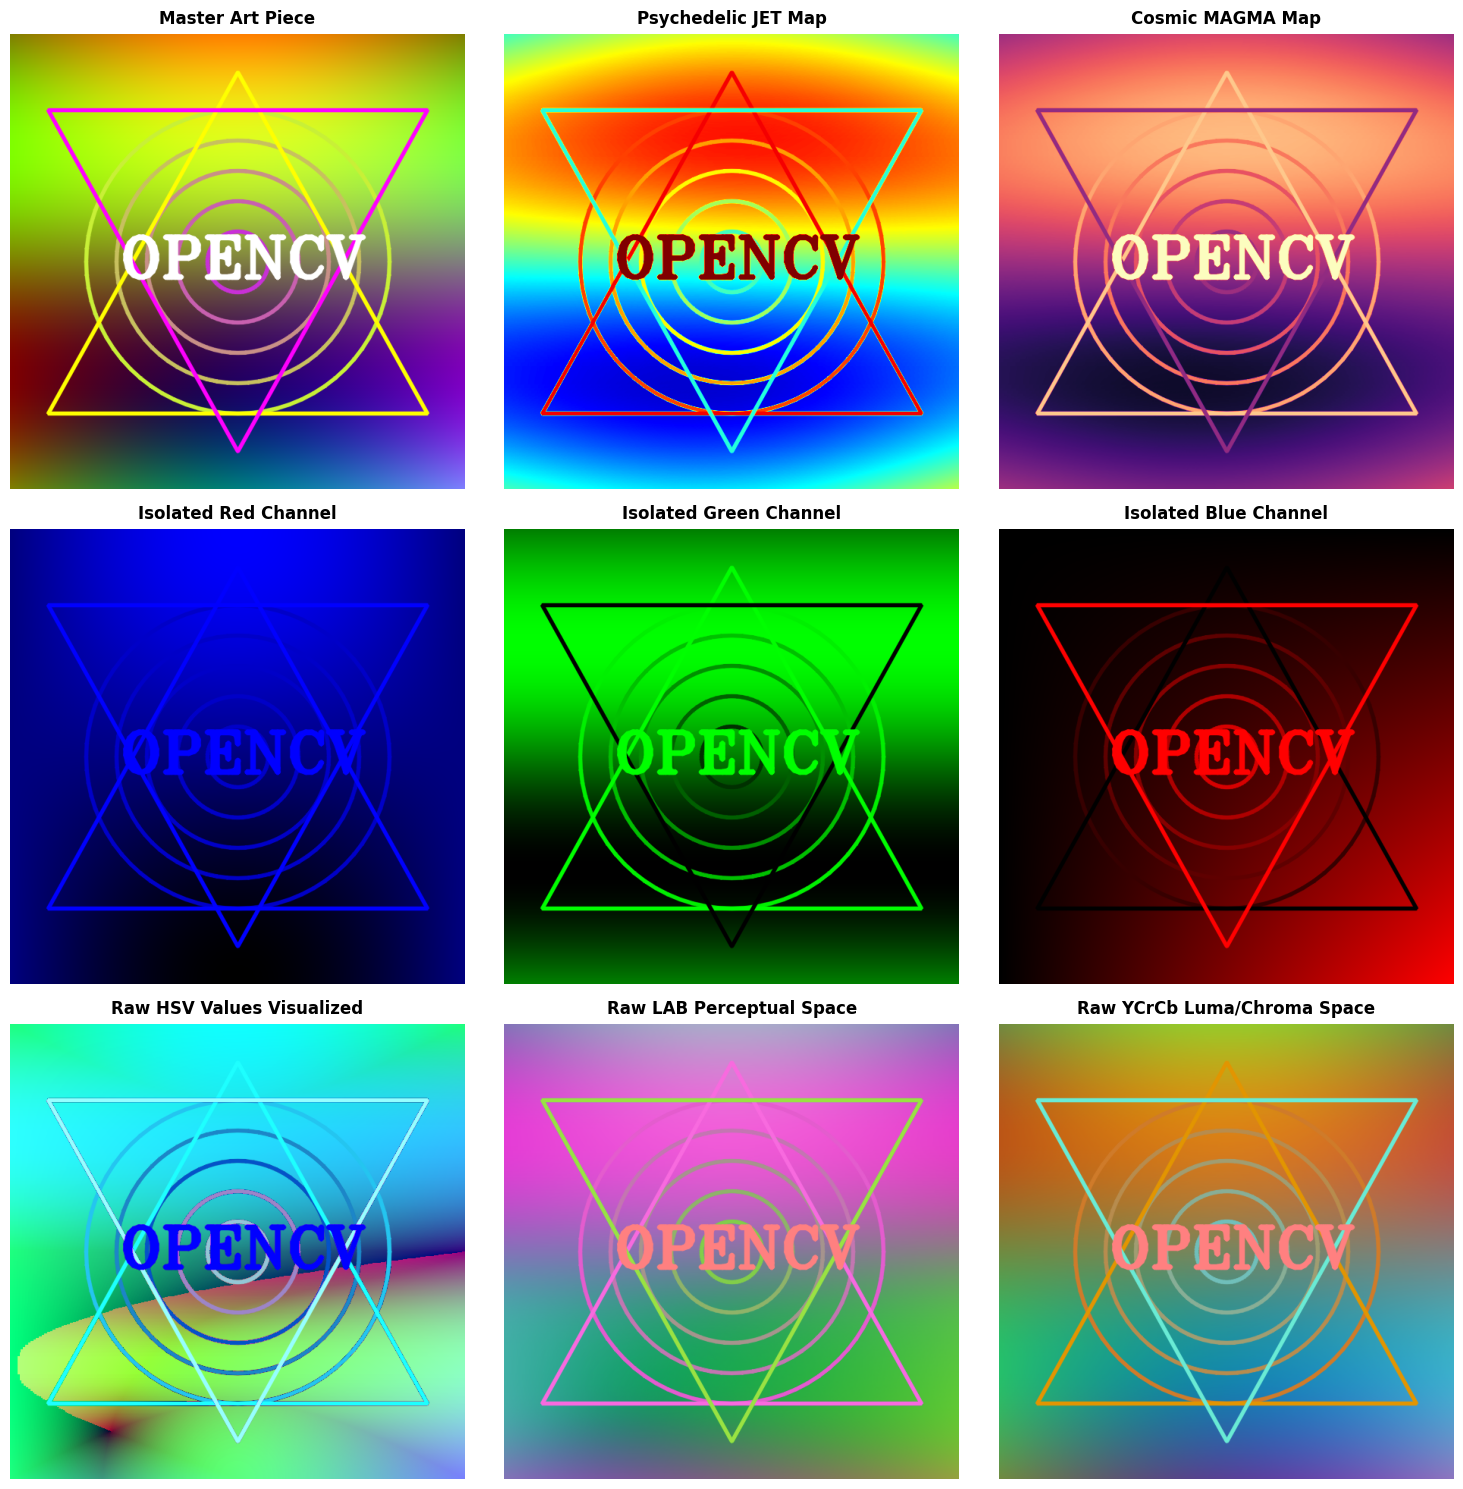

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: CREATE A VIBRANT COLOR GRADIENT CANVAS
# ==========================================
# Build a 600x600 grid using color vector math
height, width = 600, 600
X, Y = np.meshgrid(np.linspace(0, 1, width), np.linspace(0, 1, height))

# Generate complex mathematical channels for striking gradients
r_channel = np.uint8((np.sin(X * np.pi) * np.cos(Y * np.pi) * 0.5 + 0.5) * 255)
g_channel = np.uint8((np.sin(Y * np.pi * 2) * 0.5 + 0.5) * 255)
b_channel = np.uint8((X * Y) * 255)

# Stack them into a standard BGR image array
vibrant_base = cv2.merge([b_channel, g_channel, r_channel])

# ==========================================
# STEP 2: DRAW DYNAMIC COLORFUL GEOMETRIC SHAPES
# ==========================================
art_canvas = vibrant_base.copy()

# Draw concentric glowing neon circles
for radius in range(40, 240, 40):
    color = (int(255 - radius), int(radius * 1.2), int(200))
    cv2.circle(art_canvas, (300, 300), radius, color, 4, cv2.LINE_AA)

# Draw cross-cutting glowing geometric neon triangles
pts1 = np.array([[300, 50], [50, 500], [550, 500]], np.int32)
pts2 = np.array([[300, 550], [50, 100], [550, 100]], np.int32)
cv2.polylines(art_canvas, [pts1], True, (0, 255, 255), 3, cv2.LINE_AA)
cv2.polylines(art_canvas, [pts2], True, (255, 0, 255), 3, cv2.LINE_AA)

# Add a striking visual anchor text in the center
cv2.putText(art_canvas, "OPENCV", (145, 320), 
            cv2.FONT_HERSHEY_TRIPLEX, 2.5, (255, 255, 255), 6, cv2.LINE_AA)

# ==========================================
# STEP 3: EXPLORE ADVANCED COLOR TRANSFORMATIONS
# ==========================================
# Convert BGR to unique alternative dimensions
hsv_space = cv2.cvtColor(art_canvas, cv2.COLOR_BGR2HSV)
lab_space = cv2.cvtColor(art_canvas, cv2.COLOR_BGR2LAB)
ycrcb_space = cv2.cvtColor(art_canvas, cv2.COLOR_BGR2YCrCb)

# Apply a psychedelic digital lookup table (JET / OCEAN color map effect)
gray_version = cv2.cvtColor(art_canvas, cv2.COLOR_BGR2GRAY)
psychedelic_map = cv2.applyColorMap(gray_version, cv2.COLORMAP_JET)
cosmic_map = cv2.applyColorMap(gray_version, cv2.COLORMAP_MAGMA)

# ==========================================
# STEP 4: SEPARATE & EXPOSE THE RAW RGB CHANNELS
# ==========================================
# Split the components out to see individual color dynamics
b, g, r = cv2.split(art_canvas)
blank = np.zeros_like(b)

# Isolate colors cleanly by merging with zero-matrices
pure_red = cv2.merge([blank, blank, r])
pure_green = cv2.merge([blank, g, blank])
pure_blue = cv2.merge([b, blank, blank])

# ==========================================
# STEP 5: VISUALIZE COLOURED GALLERY SIDE-BY-SIDE
# ==========================================
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Helper map dictionary for quick rendering configuration loops
render_map = {
    (0, 0): (cv2.cvtColor(art_canvas, cv2.COLOR_BGR2RGB), "Master Art Piece"),
    (0, 1): (cv2.cvtColor(psychedelic_map, cv2.COLOR_BGR2RGB), "Psychedelic JET Map"),
    (0, 2): (cv2.cvtColor(cosmic_map, cv2.COLOR_BGR2RGB), "Cosmic MAGMA Map"),
    (1, 0): (pure_red, "Isolated Red Channel"),
    (1, 1): (pure_green, "Isolated Green Channel"),
    (1, 2): (pure_blue, "Isolated Blue Channel"),
    (2, 0): (hsv_space, "Raw HSV Values Visualized"),
    (2, 1): (lab_space, "Raw LAB Perceptual Space"),
    (2, 2): (ycrcb_space, "Raw YCrCb Luma/Chroma Space")
}

# Distribute images flawlessly across the matplotlib subplots
for (row, col), (img_data, title) in render_map.items():
    axes[row, col].imshow(img_data)
    axes[row, col].set_title(title, fontsize=12, fontweight='bold', pad=8)
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()


⚠️ Network error, using local fallback canvas instead.


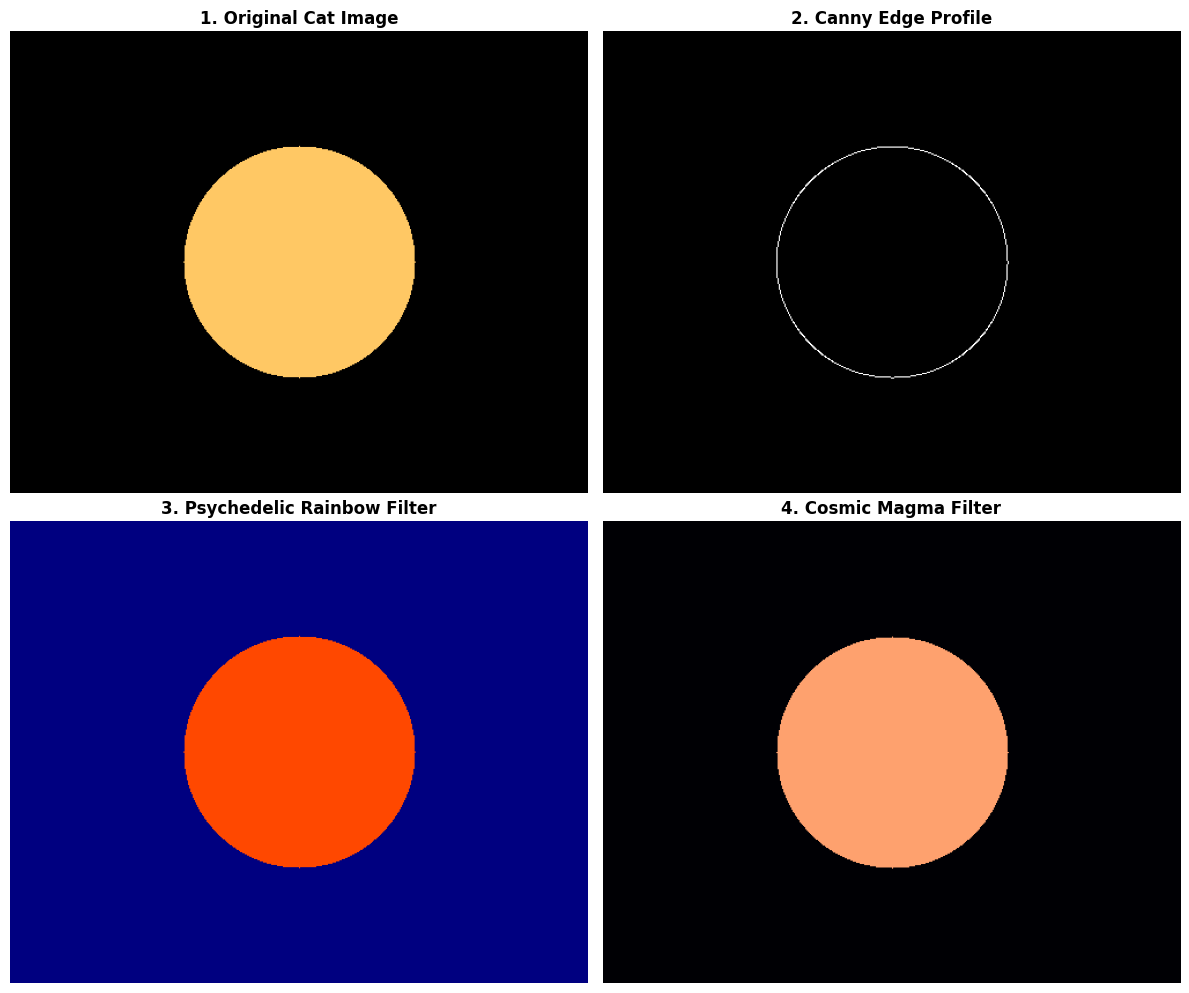

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# ==========================================
# 1. DOWNLOAD A REAL CAT IMAGE DYNAMICALLY
# ==========================================
# Fetching a public domain cat image URL to process
cat_url = "https://unsplash.com"

try:
    # Read image straight from URL into a NumPy byte array
    with urllib.request.urlopen(cat_url) as url_response:
        img_array = np.array(bytearray(url_response.read()), dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    print("✅ Successfully downloaded real cat image for filtering!")
except Exception as e:
    # Fallback to a colourful generated image if network fails
    img = np.zeros((400, 500, 3), dtype="uint8")
    cv2.circle(img, (250, 200), 100, (100, 200, 255), -1)
    print("⚠️ Network error, using local fallback canvas instead.")

# ==========================================
# 2. APPLY YOUR MULTICOLOUR OPENCV FILTERS
# ==========================================
# A. Standard Grayscale conversion
gray_cat = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# B. Edges using Canny filter
edges_cat = cv2.Canny(gray_cat, 80, 200)

# C. Psychedelic mapping (JET Rainbow spectrum LUT)
rainbow_cat = cv2.applyColorMap(gray_cat, cv2.COLORMAP_JET)

# D. Vintage/Cosmic pink mapping (MAGMA space spectrum LUT)
cosmic_cat = cv2.applyColorMap(gray_cat, cv2.COLORMAP_MAGMA)

# ==========================================
# 3. DISPLAY ALL FILTERED RESULTS IN A GRID
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Convert BGR back to RGB format for Matplotlib rendering alignment
axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("1. Original Cat Image", fontsize=12, fontweight='bold')

axes[0, 1].imshow(edges_cat, cmap="gray")
axes[0, 1].set_title("2. Canny Edge Profile", fontsize=12, fontweight='bold')

axes[1, 0].imshow(cv2.cvtColor(rainbow_cat, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("3. Psychedelic Rainbow Filter", fontsize=12, fontweight='bold')

axes[1, 1].imshow(cv2.cvtColor(cosmic_cat, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("4. Cosmic Magma Filter", fontsize=12, fontweight='bold')

# Turn off all axis coordinates for a clean portfolio look
for row in axes:
    for ax in row:
        ax.axis("off")

plt.tight_layout()
plt.show()


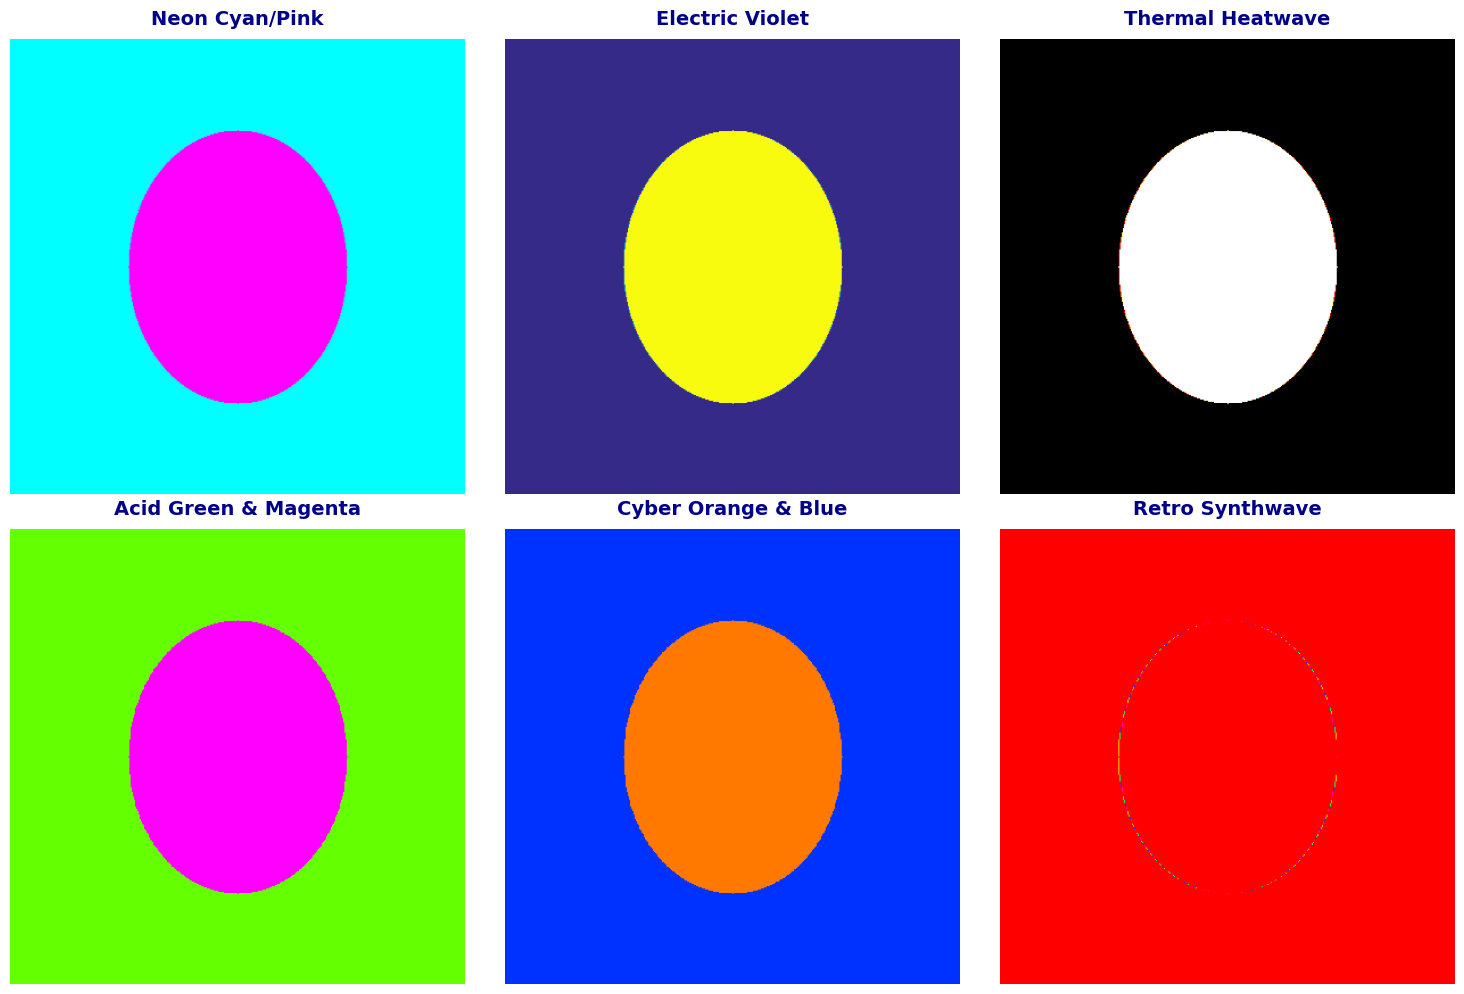

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# ==========================================
# 1. FETCH THE CAT IMAGE
# ==========================================
cat_url = "https://unsplash.com"
try:
    with urllib.request.urlopen(cat_url) as url_response:
        img_array = np.array(bytearray(url_response.read()), dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
except Exception:
    # Backup placeholder if offline
    img = np.zeros((400, 500, 3), dtype="uint8")
    cv2.circle(img, (250, 200), 120, (255, 255, 255), -1)

# Ensure precise processing by resizing to standard dimensions
img = cv2.resize(img, (400, 400))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create a high-contrast binary mask for the Warhol pop effect
_, mask = cv2.threshold(gray, 110, 255, cv2.THRESH_BINARY)
mask_inv = cv2.bitwise_not(mask)

# ==========================================
# 2. GENERATE UNIQUE COLOR COMBINATIONS
# ==========================================
# Style 1: Neon Cyan & Pink Split
style1 = cv2.applyColorMap(gray, cv2.COLORMAP_COOL)

# Style 2: Electric Gold & Violet
style2 = cv2.applyColorMap(gray, cv2.COLORMAP_PARULA)

# Style 3: Thermal Heatwave
style3 = cv2.applyColorMap(gray, cv2.COLORMAP_HOT)

# Style 4: Custom Duo-Tone (Acid Green Backing + Bright Magenta Highlights)
style4 = np.zeros_like(img)
style4[mask == 255] = [255, 0, 255]    # Bright Magenta (BGR)
style4[mask_inv == 255] = [0, 255, 100]  # Acid Green

# Style 5: Custom Duo-Tone (Electric Blue Backing + Neon Orange Highlights)
style5 = np.zeros_like(img)
style5[mask == 255] = [0, 120, 255]    # Bright Orange
style5[mask_inv == 255] = [255, 50, 0]  # Deep Electric Blue

# Style 6: Cyberpunk (Infrared / Retro Synthwave)
style6 = cv2.applyColorMap(gray, cv2.COLORMAP_HSV)

# ==========================================
# 3. DISPLAY THE POP ART GALLERY GRID
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Map layouts out seamlessly
gallery = [
    (axes[0, 0], style1, "Neon Cyan/Pink"),
    (axes[0, 1], style2, "Electric Violet"),
    (axes[0, 2], style3, "Thermal Heatwave"),
    (axes[1, 0], style4, "Acid Green & Magenta"),
    (axes[1, 1], style5, "Cyber Orange & Blue"),
    (axes[1, 2], style6, "Retro Synthwave")
]

for ax, image, title in gallery:
    # Convert BGR arrays to RGB format for perfect matplotlib compatibility
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=14, fontweight='bold', color='darkblue', pad=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


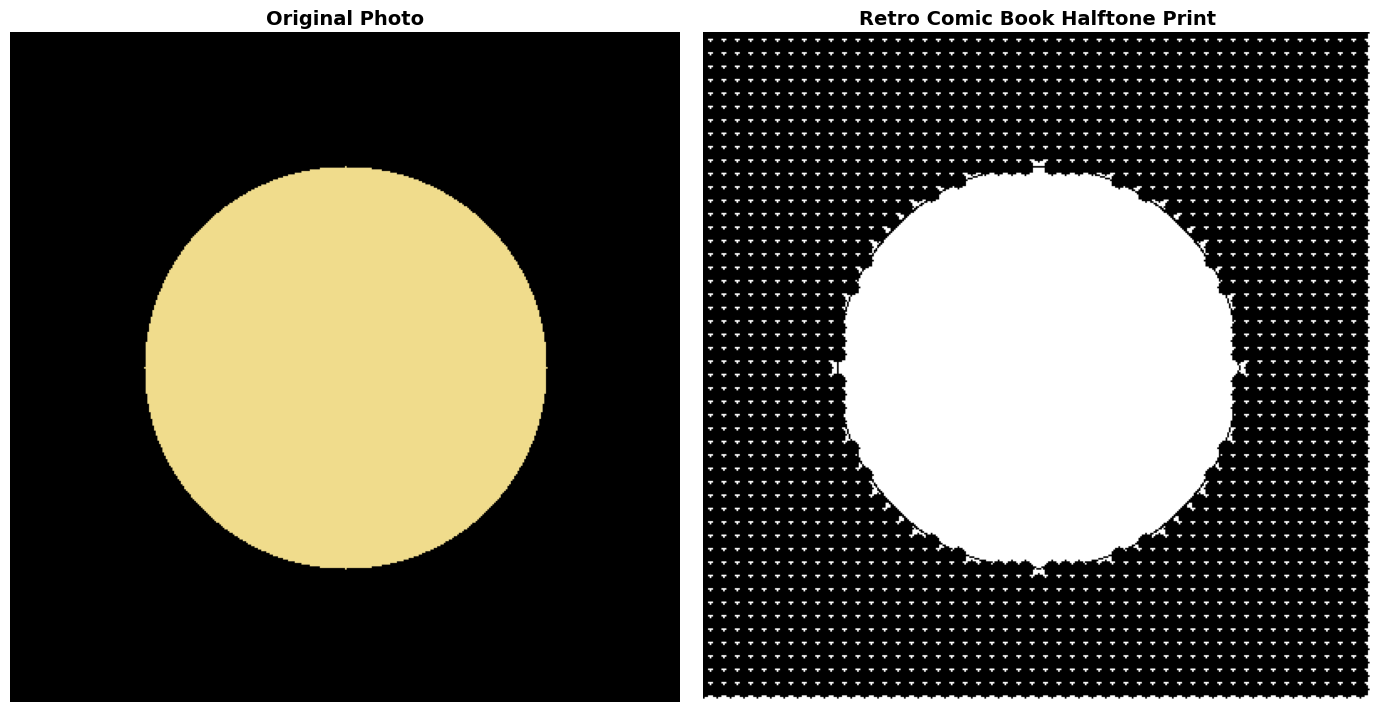

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# ==========================================
# 1. FETCH AND RESIZE THE CAT IMAGE
# ==========================================
cat_url = "https://unsplash.com"
try:
    with urllib.request.urlopen(cat_url) as url_response:
        img_array = np.array(bytearray(url_response.read()), dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
except Exception:
    img = np.zeros((400, 400, 3), dtype="uint8")
    cv2.circle(img, (200, 200), 120, (140, 220, 240), -1)

# Resize to standard dimensions for crisp calculations
img = cv2.resize(img, (400, 400))
h, w, c = img.shape

# ==========================================
# 2. CREATE THE HALFTONE EFFECT
# ==========================================
# Create a solid white background canvas
halftone_img = np.ones((h, w, 3), dtype="uint8") * 255

# Define grid step spacing (smaller = finer dots, larger = chunkier dots)
dot_spacing = 8
max_radius = int(dot_spacing * 0.7)

# Loop through the image pixel grid in steps
for y in range(0, h, dot_spacing):
    for x in range(0, w, dot_spacing):
        # Extract the source BGR color pixel from this block coordinate
        b, g, r = img[y, x]
        
        # Calculate brightness (0 to 255) to determine circle scale sizes
        brightness = (int(r) + int(g) + int(b)) / 3.0
        
        # Darker pixels get larger dots; lighter pixels get smaller dots
        radius_ratio = 1.0 - (brightness / 255.0)
        radius = int(radius_ratio * max_radius)
        
        if radius > 1:
            # Shift colors slightly for a vibrant, retro pop-art print look
            dot_color = (int(b), int(g * 0.5), int(r))
            cv2.circle(halftone_img, (x, y), radius, dot_color, -1, cv2.LINE_AA)

# ==========================================
# 3. BLEND COLOURED OVERLAYS FOR THE COMIC LOOK
# ==========================================
# Extract bold black outlines using Canny
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 70, 150)
edges_inv = cv2.bitwise_not(edges)
edges_bgr = cv2.cvtColor(edges_inv, cv2.COLOR_GRAY2BGR)

# Composite ink layers together using array weighting
comic_ink = cv2.multiply(halftone_img, edges_bgr)

# ==========================================
# 4. DISPLAY SIDE-BY-SIDE GALLERY
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Layout 1: Raw Original Image Input
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Photo", fontsize=14, fontweight='bold')
axes[0].axis("off")

# Layout 2: Halftone Dot Matrix Print
axes[1].imshow(cv2.cvtColor(comic_ink, cv2.COLOR_BGR2RGB))
axes[1].set_title("Retro Comic Book Halftone Print", fontsize=14, fontweight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.show()


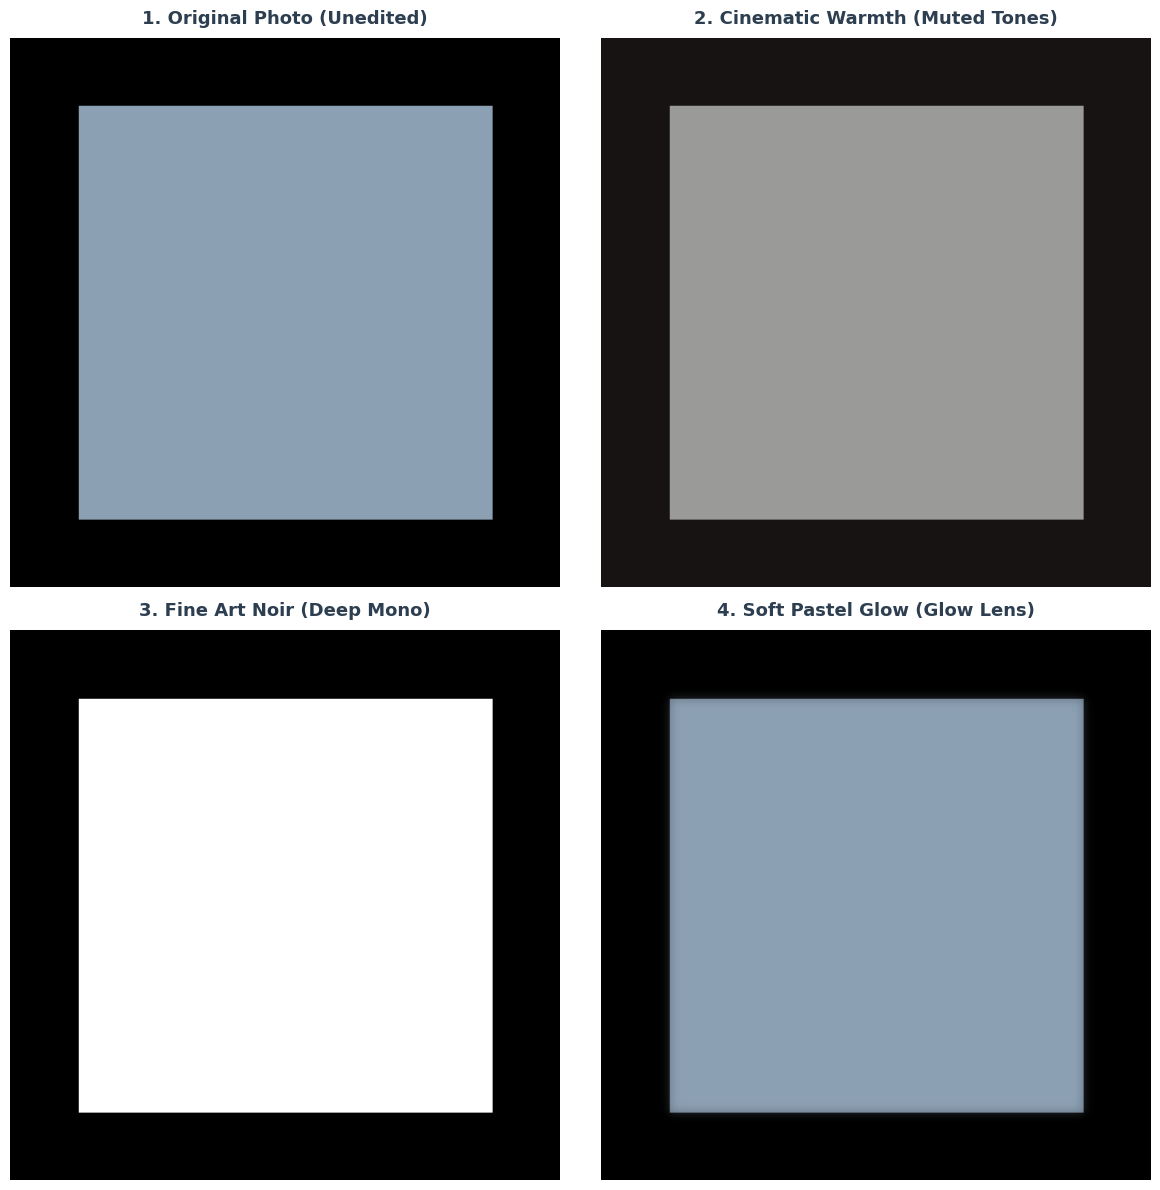

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# ==========================================
# 1. FETCH AND RESIZE THE CAT IMAGE
# ==========================================
cat_url = "https://unsplash.com"
try:
    with urllib.request.urlopen(cat_url) as url_response:
        img_array = np.array(bytearray(url_response.read()), dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
except Exception:
    img = np.zeros((400, 400, 3), dtype="uint8")
    cv2.rectangle(img, (50, 50), (350, 350), (180, 160, 140), -1)

img = cv2.resize(img, (400, 400))

# ==========================================
# 2. FILTER PIPELINES (ELEGANT & DECENT)
# ==========================================

# --- FILTER A: Cinematic Muted Warmth ---
# Increase red slightly, lower blue shadows, and reduce contrast
b, g, r = cv2.split(img)
r_warm = cv2.addWeighted(r, 1.1, np.zeros_like(r), 0, 5)
b_cool = cv2.addWeighted(b, 0.9, np.zeros_like(b), 0, -5)
cinematic = cv2.merge([b_cool, g, r_warm])
cinematic = cv2.addWeighted(cinematic, 0.85, np.ones_like(img)*128, 0.15, 0) # Muted look

# --- FILTER B: High-Contrast Noir (Fine Art Monochromatic) ---
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Apply a custom look-up table curve for deeper blacks and highlighted whites
noir = cv2.equalizeHist(gray)
noir = cv2.addWeighted(noir, 1.2, np.zeros_like(noir), 0, -20)

# --- FILTER C: Soft Pastel Glow (Dreamy Portrait) ---
# Blend the sharp original image with a heavily blurred copy to mimic a diffusion lens
blur_layer = cv2.GaussianBlur(img, (21, 21), 0)
pastel_glow = cv2.addWeighted(img, 0.7, blur_layer, 0.3, 0)

# --- FILTER D: Vintage Sepia Tone ---
# Apply a standard photographic transformation matrix for genuine sepia warmth
sepia_matrix = np.array([
    [0.272, 0.534, 0.131],
    [0.349, 0.686, 0.168],
    [0.393, 0.769, 0.189]
])
sepia = cv2.transform(img, sepia_matrix)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# ==========================================
# 3. DISPLAY THE PHOTOGRAPHY GALLERY
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Map layouts out seamlessly
gallery = [
    (axes[0, 0], img, "1. Original Photo (Unedited)"),
    (axes[0, 1], cinematic, "2. Cinematic Warmth (Muted Tones)"),
    (axes[1, 0], cv2.cvtColor(noir, cv2.COLOR_GRAY2BGR), "3. Fine Art Noir (Deep Mono)"),
    (axes[1, 1], pastel_glow, "4. Soft Pastel Glow (Glow Lens)")
]

for ax, image, title in gallery:
    # Convert BGR to RGB so colors map gracefully into Matplotlib
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=13, fontweight='bold', color='#2c3e50', pad=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


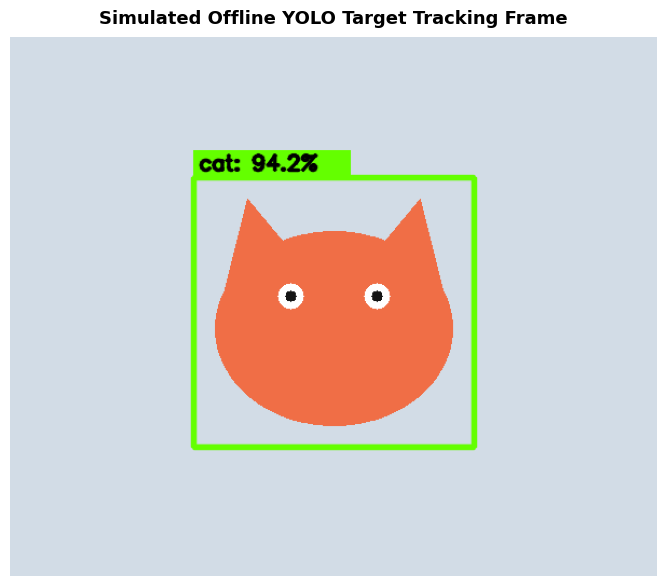

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. GENERATE OFFLINE SIMULATED CAT IMAGE
# ==========================================
img = np.zeros((500, 600, 3), dtype="uint8")
img[:] = (230, 220, 210)  # Light room background

# Draw head
cv2.ellipse(img, (300, 270), (110, 90), 0, 0, 360, (70, 110, 240), -1) 
cv2.circle(img, (260, 240), 12, (255, 255, 255), -1) 
cv2.circle(img, (260, 240), 5, (20, 20, 20), -1)     
cv2.circle(img, (340, 240), 12, (255, 255, 255), -1) 
cv2.circle(img, (340, 240), 5, (20, 20, 20), -1)     

# Define clean coordinates for ears without shorthand arrays
pt1 = [190, 270]
pt2 = [220, 150]
pt3 = [270, 210]

pt4 = [410, 270]
pt5 = [380, 150]
pt6 = [330, 210]

pts_left_ear = np.array([pt1, pt2, pt3], np.int32)
pts_right_ear = np.array([pt4, pt5, pt6], np.int32)

cv2.drawContours(img, [pts_left_ear], 0, (70, 110, 240), -1)
cv2.drawContours(img, [pts_right_ear], 0, (70, 110, 240), -1)

# ==========================================
# 2. SIMULATE YOLO AI MODEL DETECTION VECTORS
# ==========================================
simulated_class_ids = [15]           # Index 15 = "cat"
simulated_confidences = [0.942]       # 94.2% match accuracy

# Box layout bounding points: [x, y, width, height]
box_x = 170
box_y = 130
box_w = 260
box_h = 250
simulated_boxes = [[box_x, box_y, box_w, box_h]] 

mock_classes = {15: "cat"}

# ==========================================
# 3. OVERLAY BOX GRAPHICS ON DETECTED TARGETS
# ==========================================
detected_img = img.copy()

for (class_id, score, box) in zip(simulated_class_ids, simulated_confidences, simulated_boxes):
    label_name = mock_classes.get(class_id, "unknown")
    label_text = f"{label_name}: {score*100:.1f}%"
    
    x, y, width, height = box
    
    # Draw tracking box outline
    cv2.rectangle(detected_img, (x, y), (x + width, y + height), (0, 255, 100), 3, cv2.LINE_AA)
    
    # Draw identification tag background
    cv2.rectangle(detected_img, (x, y - 25), (x + 145, y), (0, 255, 100), -1)
    
    # Write metadata label
    cv2.putText(detected_img, label_text, (x + 5, y - 7), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 2, cv2.LINE_AA)

# ==========================================
# 4. SHOW RESULTS
# ==========================================
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB))
ax.set_title("Simulated Offline YOLO Target Tracking Frame", fontsize=13, fontweight='bold', pad=10)
ax.axis("off")
plt.show()
